Load & Read Data 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

customers = pd.read_csv("E:\\DS\\Assignment\\customers.csv")
orders = pd.read_csv("E:\\DS\\Assignment\\orders.csv")
order_items = pd.read_csv("E:\\DS\\Assignment\\order_items.csv")
products = pd.read_csv("E:\\DS\\Assignment\\products.csv")
returns = pd.read_csv("E:\\DS\\Assignment\\returns.csv")
# \DS gives error. So, "\\" or "r" prevents such error.


 Data Details Before Cleaning & Pre-proccesing

In [12]:
customers.info()
orders.info()
order_items.info()
products.info()
returns.info()

# There is no null values in any Dataset and Date is stored in String Value.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        100 non-null    int64 
 1   customer_name      100 non-null    object
 2   gender             100 non-null    object
 3   age                100 non-null    int64 
 4   city               100 non-null    object
 5   registration_date  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        300 non-null    int64 
 1   customer_id     300 non-null    int64 
 2   order_date      300 non-null    object
 3   payment_method  300 non-null    object
 4   order_status    300 non-null    object
dtypes: int64(2), object(3)
memory usage: 11.8+ KB
<class '

In [13]:
customers['registration_date'] = pd.to_datetime(customers['registration_date']) 
orders['order_date'] = pd.to_datetime(orders['order_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])

customers.info()
orders.info()
order_items.info()
products.info()
returns.info()

# Dates converted into its Proper format.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        100 non-null    int64         
 1   customer_name      100 non-null    object        
 2   gender             100 non-null    object        
 3   age                100 non-null    int64         
 4   city               100 non-null    object        
 5   registration_date  100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[ns]
 3   payment_method  300

Data Preparation 

In [14]:
orders_items_merged = pd.merge(orders, order_items, on='order_id', how='inner')
orders_items_products = pd.merge(orders_items_merged, products, on='product_id', how='inner')
full_data = pd.merge(orders_items_products, customers, on='customer_id', how='left')

print(full_data)

# To calculate the data that were in different table Merge/Join is used on Orders, Orders_item and Products.

     order_id  customer_id order_date payment_method order_status  \
0           1            1 2024-01-30           Card    Delivered   
1           1            1 2024-01-30           Card    Delivered   
2           1            1 2024-01-30           Card    Delivered   
3           2           34 2024-04-18         Wallet     Returned   
4           2           34 2024-04-18         Wallet     Returned   
..        ...          ...        ...            ...          ...   
495       299           10 2024-04-29           Card    Delivered   
496       300           56 2024-05-16            COD    Delivered   
497       300           56 2024-05-16            COD    Delivered   
498       300           56 2024-05-16            COD    Delivered   
499       300           56 2024-05-16            COD    Delivered   

     order_item_id  product_id  quantity  discount product_name     category  \
0              205          23         4       200   Product 23      Fashion   
1          

In [15]:
full_data['revenue'] = full_data['quantity'] * full_data['selling_price']
# This revenue does not contain discount.

full_data['discount_amount'] = full_data['discount']


full_data['net_revenue'] = full_data['revenue'] - full_data['discount_amount']
# Net revenue contains revenue after discount, is used for calculating total revenue.

# For simplification new column is made by calculating pervious given values.

print(full_data)

     order_id  customer_id order_date payment_method order_status  \
0           1            1 2024-01-30           Card    Delivered   
1           1            1 2024-01-30           Card    Delivered   
2           1            1 2024-01-30           Card    Delivered   
3           2           34 2024-04-18         Wallet     Returned   
4           2           34 2024-04-18         Wallet     Returned   
..        ...          ...        ...            ...          ...   
495       299           10 2024-04-29           Card    Delivered   
496       300           56 2024-05-16            COD    Delivered   
497       300           56 2024-05-16            COD    Delivered   
498       300           56 2024-05-16            COD    Delivered   
499       300           56 2024-05-16            COD    Delivered   

     order_item_id  product_id  quantity  discount product_name  ...  \
0              205          23         4       200   Product 23  ...   
1              224         

In [16]:
total_revenue = full_data['net_revenue'].sum()
print(f"Total Revenue: RS.{total_revenue:,.2f}")

# Sums/Adds all net revenue till date which gives total revenue.

Total Revenue: RS.4,743,668.00


In [17]:
full_data['order_month'] = full_data['order_date'].dt.to_period('M')
#This uses datetime to convert all the date to period'M' 

monthly_revenue = full_data.groupby('order_month')['net_revenue'].sum().reset_index()
# This groups all the months and sums/add revenue according to its months and gets back to its column.

monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)
# Converts the pervious period data of Months into

full_data.info()
print(monthly_revenue)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           500 non-null    int64         
 1   customer_id        500 non-null    int64         
 2   order_date         500 non-null    datetime64[ns]
 3   payment_method     500 non-null    object        
 4   order_status       500 non-null    object        
 5   order_item_id      500 non-null    int64         
 6   product_id         500 non-null    int64         
 7   quantity           500 non-null    int64         
 8   discount           500 non-null    int64         
 9   product_name       500 non-null    object        
 10  category           500 non-null    object        
 11  cost_price         500 non-null    int64         
 12  selling_price      500 non-null    int64         
 13  customer_name      500 non-null    object        
 14  gender    

In [18]:
product_revenue = full_data.groupby(['product_id', 'product_name', 'category']).agg({
    'net_revenue': 'sum',
    'quantity': 'sum'
}).reset_index()
# This groups products info, net revenue and quantity then revenue and quantity is summed after which will be stored in place.


top_10_products = product_revenue.nlargest(10, 'net_revenue')

print(top_10_products)


    product_id product_name     category  net_revenue  quantity
2            3    Product 3  Electronics       333471        59
7            8    Product 8      Fashion       309335        59
9           10   Product 10      Fashion       306325        51
22          23   Product 23      Fashion       296106        44
18          19   Product 19         Home       294160        43
17          18   Product 18      Fashion       291473        49
12          13   Product 13      Fashion       265546        48
1            2    Product 2         Home       255930        42
6            7    Product 7         Home       241658        47
29          30   Product 30      Fashion       231118        42


Data Visualization:


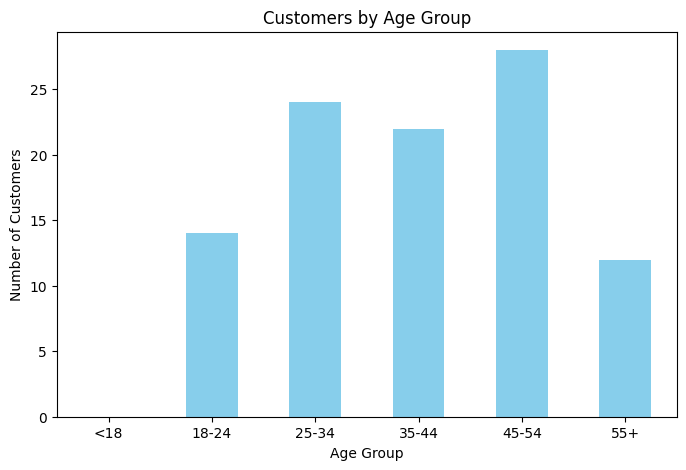

In [19]:

bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55+']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)
#  Create age groups

age_counts = customers['age_group'].value_counts().sort_index()
# This Count customers in each age group.

plt.figure(figsize=(8,5))
age_counts.plot(kind='bar', color='skyblue')
plt.title("Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# The graphs shows that the age between 45-54 are the highest among other age group.

C:\Users\thapa\AppData\Local\Temp\ipykernel_6456\3762186358.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_revenue = customer_age_revenue.groupby('age_group')['net_revenue'].sum().reset_index()


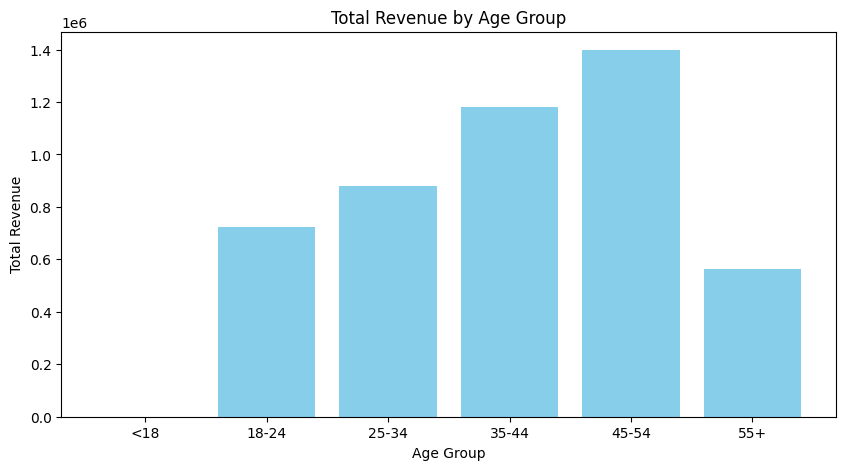

In [20]:

customer_age_revenue = pd.merge(
    full_data.groupby('customer_id')['net_revenue'].sum().reset_index(),
    customers[['customer_id', 'age_group']],
    on='customer_id',
    how='left'
)
# Aggregate total revenue per customer and age group.


age_group_revenue = customer_age_revenue.groupby('age_group')['net_revenue'].sum().reset_index()
# Aggregate total revenue by age group.


plt.figure(figsize=(10,5))
plt.bar(age_group_revenue['age_group'], age_group_revenue['net_revenue'], color='skyblue')
plt.title("Total Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()
# Plot total revenue by age group

In [22]:

returns_data = pd.merge(returns, orders, on='order_id', how='left')
returns_data = pd.merge(returns_data, order_items, on='order_id', how='left')
returns_data = pd.merge(returns_data, products, on='product_id', how='left')
returns_data = pd.merge(returns_data, customers, on='customer_id', how='left')

returns_data.info()
# For Return Analysis, Merge data to connect returns with customers and products.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   return_id          56 non-null     int64         
 1   order_id           56 non-null     int64         
 2   return_reason      56 non-null     object        
 3   return_date        56 non-null     datetime64[ns]
 4   customer_id        56 non-null     int64         
 5   order_date         56 non-null     datetime64[ns]
 6   payment_method     56 non-null     object        
 7   order_status       56 non-null     object        
 8   order_item_id      47 non-null     float64       
 9   product_id         47 non-null     float64       
 10  quantity           47 non-null     float64       
 11  discount           47 non-null     float64       
 12  product_name       47 non-null     object        
 13  category           47 non-null     object        
 14  cost_price  

In [ ]:

returns_data['age_group'] = pd.cut(returns_data['age'], 
                                   bins=[0, 25, 35, 45, 100],
                                   labels=['<25', '25-34', '35-44', '45+'])


age_returns = returns_data['age_group'].value_counts()
print(age_returns)
# Create age groups and the returns by age group


product_returns = returns_data['product_name'].value_counts()
print(product_returns.head(5))
# Count returns by product


age_group
45+      21
35-44    17
25-34    11
<25       7
Name: count, dtype: int64
product_name
Product 22    4
Product 13    4
Product 9     3
Product 3     3
Product 8     3
Name: count, dtype: int64


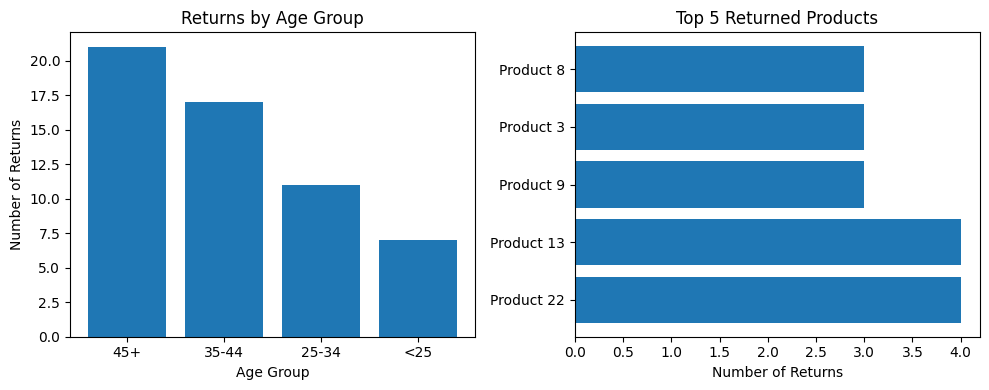

In [27]:
# Create simple visualization
plt.figure(figsize=(10, 4))

# First plot: Age groups
plt.subplot(1, 2, 1)
plt.bar(age_returns.index, age_returns.values)
plt.title('Returns by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Returns')

# Second plot: Top products
plt.subplot(1, 2, 2)
top_5 = product_returns.head(5)
plt.barh(top_5.index, top_5.values)
plt.title('Top 5 Returned Products')
plt.xlabel('Number of Returns')

plt.tight_layout()
plt.show()